# CIFAR-10 Classification Pipeline
**PUC-Campinas · Engenharia de Software · IAAM · Avaliação Prática 2**

---

# Integrantes do grupo:

João Pedro Duarte Giatti - 24019083

Jean Yuki Kimura - 24008214

Eduarda Luiza Pinheiro Nepomuceno - 24002529

## 1. Importações

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
import  torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset
from collections import Counter

RANDOM_STATE = 2025
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# DEVICE
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}')

Device: cpu
PyTorch: 2.12.0+cpu | Torchvision: 0.27.0+cpu


## 2. Carregamento do Dataset

In [9]:
# transform mínimo para carregamento inicial (apenas tensor, sem normalização ainda)
raw_transform = transforms.ToTensor()

# carrega treino + teste do CIFAR-10
cifar_train_raw = CIFAR10(root='./data', train=True,  download=True, transform=raw_transform)
cifar_test_raw  = CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

# Nomes das 10 classes
CLASS_NAMES = cifar_train_raw.classes
print('Classes:', CLASS_NAMES)
print(f'Treino (raw): {len(cifar_train_raw)} amostras')
print(f'Teste  (raw): {len(cifar_test_raw)}  amostras')

# Armazena estrutura indexável features + labels
dataset = cifar_train_raw + cifar_test_raw # (60 000 amostras)
print(f'dataset total : {len(dataset)} amostras')
print(f'Forma de uma amostra — imagem: {dataset[0][0].shape}, label: {dataset[0][1]}')

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Treino (raw): 50000 amostras
Teste  (raw): 10000  amostras
dataset total : 60000 amostras
Forma de uma amostra — imagem: torch.Size([3, 32, 32]), label: 6


## 3. Visualização Inicial

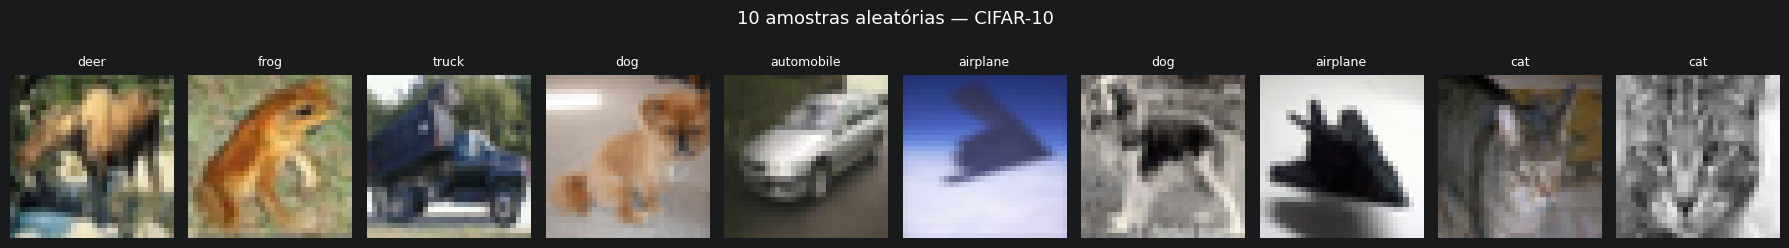

In [12]:
# 10 amostras aleatórias
rng = random.Random(RANDOM_STATE)
sample_indices = rng.sample(range(len(dataset)), 10)

fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
fig.suptitle('10 amostras aleatórias — CIFAR-10', fontsize=13, y=1.02)

for ax, idx in zip(axes, sample_indices):
    img_tensor, label = dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()   # CHW → HWC
    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# contagem por classe
all_labels = [dataset[i][1] for i in range(len(dataset))]
counts = Counter(all_labels)

print(f'{"Classe":<15} {"ID":>4} {"Total":>8}')
print('-' * 30)
for cid, cname in enumerate(CLASS_NAMES):
    print(f'{cname:<15} {cid:>4} {counts[cid]:>8}')
print('-' * 30)
print(f'{"TOTAL":<15} {"":>4} {sum(counts.values()):>8}')

Classe            ID    Total
------------------------------
airplane           0     6000
automobile         1     6000
bird               2     6000
cat                3     6000
deer               4     6000
dog                5     6000
frog               6     6000
horse              7     6000
ship               8     6000
truck              9     6000
------------------------------
TOTAL                   60000


In [14]:
# ── 3.3  Forma dos dados ─────────────────────────────────────────────────────
sample_img, sample_lbl = dataset[0]
print('Forma da imagem (C, H, W):', tuple(sample_img.shape))
print('Tipo do tensor           :', sample_img.dtype)
print('Valor mín / máx          :', sample_img.min().item(), '/', sample_img.max().item())
print('Total de classes         :', len(CLASS_NAMES))
print('Total de amostras no Dataset:', len(dataset))

Forma da imagem (C, H, W): (3, 32, 32)
Tipo do tensor           : torch.float32
Valor mín / máx          : 0.0 / 1.0
Total de classes         : 10
Total de amostras no Dataset: 60000


## 3. Pré-processamento e Data Augmentation

In [16]:
# Média e desvio padrão por canal do CIFAR-10 (valores padrão da literatura)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Transform para TREINO — com augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Transform para VALIDAÇÃO e TESTE — sem augmentation, só normaliza
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

print('Transform treino:')
print(transform_train)
print('\nTransform validação/teste:')
print(transform_eval)

Transform treino:
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

Transform validação/teste:
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


## 4. Divisão dos Dados — Treino / Validação / Teste

In [24]:
from sklearn.model_selection import train_test_split

# Labels do dataset completo (60k amostras)
all_labels = [dataset[i][1] for i in range(len(dataset))]
indices = list(range(len(dataset)))

# Split estratificado: 70% treino, 30% restante
idx_train, idx_temp = train_test_split(
    indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=RANDOM_STATE
)

# Split do restante: 50% validação, 50% teste (= 15% e 15% do total)
labels_temp = [all_labels[i] for i in idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    stratify=labels_temp,
    random_state=RANDOM_STATE
)

print(f'Treino     : {len(idx_train):>6} amostras ({len(idx_train)/len(dataset)*100:.1f}%)')
print(f'Validação  : {len(idx_val):>6} amostras ({len(idx_val)/len(dataset)*100:.1f}%)')
print(f'Teste      : {len(idx_test):>6} amostras ({len(idx_test)/len(dataset)*100:.1f}%)')

Treino     :  42000 amostras (70.0%)
Validação  :   9000 amostras (15.0%)
Teste      :   9000 amostras (15.0%)


In [33]:
from torchvision.datasets import CIFAR10

# Dataset completo com cada transform
cifar_train_ds = CIFAR10(root='./data', train=True,  download=False, transform=transform_train)
cifar_eval_ds  = CIFAR10(root='./data', train=True,  download=False, transform=transform_eval)
cifar_test_ds  = CIFAR10(root='./data', train=False, download=False, transform=transform_eval)

# Os 60k do dataset foram: índices 0~49999 = train=True, 50000~59999 = train=False
# Precisa mapear os índices corretamente
def split_indices(indices):
    train_idx = [i for i in indices if i < 50000]
    test_idx  = [i - 50000 for i in indices if i >= 50000]
    return train_idx, test_idx

train_train_idx, train_test_idx = split_indices(idx_train)
val_train_idx,   val_test_idx   = split_indices(idx_val)
test_train_idx,  test_test_idx  = split_indices(idx_test)

from torch.utils.data import ConcatDataset

train_dataset = ConcatDataset([Subset(cifar_train_ds, train_train_idx), Subset(cifar_test_ds, train_test_idx)])
val_dataset   = ConcatDataset([Subset(cifar_eval_ds,  val_train_idx),   Subset(cifar_test_ds, val_test_idx)])
test_dataset  = ConcatDataset([Subset(cifar_eval_ds,  test_train_idx),  Subset(cifar_test_ds, test_test_idx)])

g = torch.Generator()
g.manual_seed(RANDOM_STATE)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  generator=g, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0)

print('DataLoaders criados!')
print(f'Batches treino    : {len(train_loader)}')
print(f'Batches validação : {len(val_loader)}')
print(f'Batches teste     : {len(test_loader)}')

DataLoaders criados!
Batches treino    : 329
Batches validação : 71
Batches teste     : 71


In [34]:
# Tabela de amostras por classe em cada partição
print(f'{"Classe":<15} {"Treino":>8} {"Validação":>10} {"Teste":>8}')
print('-' * 45)

train_labels = [dataset[i][1] for i in idx_train]
val_labels   = [dataset[i][1] for i in idx_val]
test_labels  = [dataset[i][1] for i in idx_test]

c_train = Counter(train_labels)
c_val   = Counter(val_labels)
c_test  = Counter(test_labels)

for cid, cname in enumerate(CLASS_NAMES):
    print(f'{cname:<15} {c_train[cid]:>8} {c_val[cid]:>10} {c_test[cid]:>8}')

print('-' * 45)
print(f'{"TOTAL":<15} {len(idx_train):>8} {len(idx_val):>10} {len(idx_test):>8}')

Classe            Treino  Validação    Teste
---------------------------------------------
airplane            4200        900      900
automobile          4200        900      900
bird                4200        900      900
cat                 4200        900      900
deer                4200        900      900
dog                 4200        900      900
frog                4200        900      900
horse               4200        900      900
ship                4200        900      900
truck               4200        900      900
---------------------------------------------
TOTAL              42000       9000     9000


## 5. Arquitetura da CNN

In [35]:
import torch.nn as nn

class ClfGen(nn.Module):
    def __init__(self):
        super(ClfGen, self).__init__()

        # Layer 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)         # 32x32 → 16x16
        )

        # Layer 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)         # 16x16 → 8x8
        )

        # Head
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Flatten(),              # 64 * 8 * 8 = 4096
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)         # logits — CrossEntropy já aplica softmax
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.head(x)
        return x

# Instancia o modelo
clfgen = ClfGen().to(DEVICE)
print(clfgen)

ClfGen(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (he

In [36]:
# Resumo do modelo — total de parâmetros
total_params = sum(p.numel() for p in clfgen.parameters())
train_params = sum(p.numel() for p in clfgen.parameters() if p.requires_grad)

print(f'Total de parâmetros    : {total_params:,}')
print(f'Parâmetros treináveis  : {train_params:,}')

# Teste rápido com um batch falso
dummy = torch.zeros(1, 3, 32, 32).to(DEVICE)
out   = clfgen(dummy)
print(f'\nEntrada : {tuple(dummy.shape)}')
print(f'Saída   : {tuple(out.shape)}  (10 logits, um por classe)')

Total de parâmetros    : 1,117,354
Parâmetros treináveis  : 1,117,354

Entrada : (1, 3, 32, 32)
Saída   : (1, 10)  (10 logits, um por classe)


## 6. Treinamento com Validação

In [37]:
import torch.optim as optim
import copy

# Otimizador e scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clfgen.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

# Early stopping
EARLY_STOPPING_PATIENCE = 10
best_val_acc   = 0.0
best_model_wts = copy.deepcopy(clfgen.state_dict())
epochs_no_improve = 0
NUM_EPOCHS = 100

# Histórico
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Iniciando treino — até {NUM_EPOCHS} épocas, early stopping após {EARLY_STOPPING_PATIENCE} sem melhora')
print(f'Otimizador: Adam lr=1e-3 | Scheduler: ReduceLROnPlateau | Device: {DEVICE}')
print('-' * 70)

Iniciando treino — até 100 épocas, early stopping após 10 sem melhora
Otimizador: Adam lr=1e-3 | Scheduler: ReduceLROnPlateau | Device: cpu
----------------------------------------------------------------------


In [38]:
for epoch in range(1, NUM_EPOCHS + 1):

    # ── TREINO ──────────────────────────────────────────────────────────────
    clfgen.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = clfgen(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # ── VALIDAÇÃO ───────────────────────────────────────────────────────────
    clfgen.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs  = clfgen(images)
            loss     = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    # Salva histórico
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Scheduler step
    scheduler.step(val_acc)

    # Salva melhor modelo
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(clfgen.state_dict())
        torch.save(best_model_wts, 'best_clfgen.pth')
        flag = '  ← melhor!'
        epochs_no_improve = 0
    else:
        flag = ''
        epochs_no_improve += 1

    print(f'Época {epoch:>3}/{NUM_EPOCHS} | '
          f'Loss treino: {train_loss:.4f} | Acc treino: {train_acc:.4f} | '
          f'Loss val: {val_loss:.4f} | Acc val: {val_acc:.4f}{flag}')

    # Early stopping
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping na época {epoch} — sem melhora há {EARLY_STOPPING_PATIENCE} épocas.')
        break

print(f'\nMelhor acurácia de validação: {best_val_acc:.4f}')
print('Modelo salvo em best_clfgen.pth')

Época   1/100 | Loss treino: 1.7553 | Acc treino: 0.3512 | Loss val: 1.3741 | Acc val: 0.5044  ← melhor!
Época   2/100 | Loss treino: 1.4447 | Acc treino: 0.4684 | Loss val: 1.2054 | Acc val: 0.5533  ← melhor!
Época   3/100 | Loss treino: 1.2883 | Acc treino: 0.5294 | Loss val: 1.0253 | Acc val: 0.6260  ← melhor!
Época   4/100 | Loss treino: 1.1981 | Acc treino: 0.5701 | Loss val: 0.9957 | Acc val: 0.6411  ← melhor!
Época   5/100 | Loss treino: 1.1286 | Acc treino: 0.5947 | Loss val: 0.8829 | Acc val: 0.6821  ← melhor!
Época   6/100 | Loss treino: 1.0873 | Acc treino: 0.6136 | Loss val: 0.8745 | Acc val: 0.6864  ← melhor!
Época   7/100 | Loss treino: 1.0477 | Acc treino: 0.6304 | Loss val: 0.8755 | Acc val: 0.6891  ← melhor!
Época   8/100 | Loss treino: 1.0093 | Acc treino: 0.6425 | Loss val: 0.8694 | Acc val: 0.6962  ← melhor!
Época   9/100 | Loss treino: 0.9774 | Acc treino: 0.6545 | Loss val: 0.7625 | Acc val: 0.7256  ← melhor!
Época  10/100 | Loss treino: 0.9494 | Acc treino: 0.664

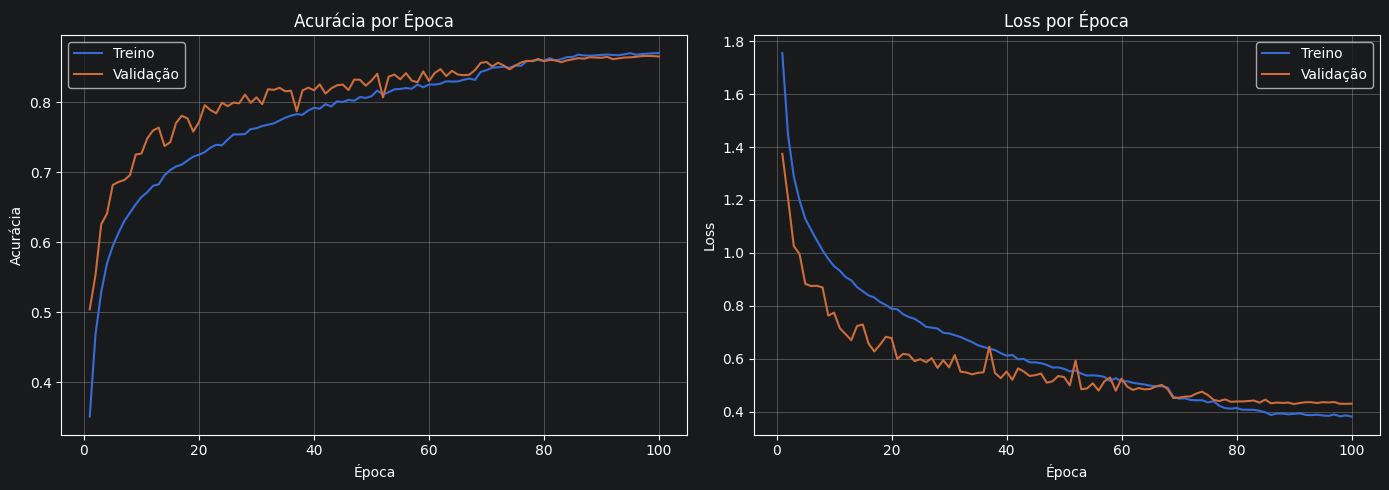

In [39]:
# Curvas de treino vs validação
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(x, history['train_acc'], label='Treino')
axes[0].plot(x, history['val_acc'],   label='Validação')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(x, history['train_loss'], label='Treino')
axes[1].plot(x, history['val_loss'],   label='Validação')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()